In [2]:
!pip install -q pandas numpy matplotlib seaborn gradio sentence-transformers faiss-cpu google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 65.7 MB/s eta 0:00:00


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import gradio as gr

from sentence_transformers import SentenceTransformer
from google import genai

In [ ]:
GEMINI_API_KEY= input("API HERE")
client= genai.Client(api_key= GEMINI_API_KEY)
print("Gemini API configured succesfully.")

In [5]:
os.makedirs("/content/documents", exist_ok=True)

hr_policy = """
Employee Leave Policy

Employees receive 18 paid leave days per year.
Employees should submit planned leave requests at least 3 working days before the leave date.
Emergency leave should be communicated to the reporting manager as soon as possible.
Managers are responsible for approving or rejecting leave requests.
Employees should check their remaining leave balance before submitting a request.
"""

it_policy = """
IT Security Policy

Employees must use strong passwords for company systems.
Passwords should not be shared with other employees.
Multi-factor authentication should be enabled for important company applications.
Company laptops should be locked whenever employees leave their desks.
Employees must report suspicious emails to the IT security team.
"""

work_from_home = """
Work From Home Policy

Employees may request work from home when business requirements allow it.
The request should normally be submitted to the manager before the working day begins.
Employees working remotely must remain available during normal working hours.
Company information must not be shared through personal email accounts.
Employees must follow all company security policies while working remotely.
"""

with open("/content/documents/hr_policy.txt", "w") as f:
    f.write(hr_policy)

with open("/content/documents/it_security_policy.txt", "w") as f:
    f.write(it_policy)

with open("/content/documents/work_from_home_policy.txt", "w") as f:
    f.write(work_from_home)

print("Sample documents created successfully.")

Sample documents created successfully.


In [6]:
document_folder= "/content/documents"
files= os.listdir(document_folder)
print("Available documents:")
for file in files:
    print(file)

Available documents:
work_from_home_policy.txt
it_security_policy.txt
hr_policy.txt


In [7]:
documents= []
for file in files:
    file_path= os.path.join(document_folder, file)
    with open(file_path, "r", encoding="utf-8")as f:
      text= f.read()
      documents.append({
          "Document":file,
          "Text":text
      })
      documents_df= pd.DataFrame(documents)
      print(documents_df)

                    Document  \
0  work_from_home_policy.txt   

                                                Text  
0  \nWork From Home Policy\n\nEmployees may reque...  
                    Document  \
0  work_from_home_policy.txt   
1     it_security_policy.txt   

                                                Text  
0  \nWork From Home Policy\n\nEmployees may reque...  
1  \nIT Security Policy\n\nEmployees must use str...  
                    Document  \
0  work_from_home_policy.txt   
1     it_security_policy.txt   
2              hr_policy.txt   

                                                Text  
0  \nWork From Home Policy\n\nEmployees may reque...  
1  \nIT Security Policy\n\nEmployees must use str...  
2  \nEmployee Leave Policy\n\nEmployees receive 1...  


In [8]:
def split_text(text, chunk_size=80):
    words = text.split()

    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])

        if chunk.strip():
            chunks.append(chunk)

    return chunks

In [9]:
chunk_records = []

for i in range(len(documents_df)):

    document_name = documents_df.loc[i, "Document"]
    text = documents_df.loc[i, "Text"]

    chunks = split_text(text)

    for chunk in chunks:

        chunk_records.append({
            "Document": document_name,
            "Chunk": chunk
        })

chunks_df = pd.DataFrame(chunk_records)

print(chunks_df)

                    Document  \
0  work_from_home_policy.txt   
1     it_security_policy.txt   
2              hr_policy.txt   

                                               Chunk  
0  Work From Home Policy Employees may request wo...  
1  IT Security Policy Employees must use strong p...  
2  Employee Leave Policy Employees receive 18 pai...  


In [10]:
print("Total Documents:", chunks_df["Document"].nunique())
print("Total Chunks:", len(chunks_df))

Total Documents: 3
Total Chunks: 3


In [11]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully.


In [12]:
texts = chunks_df["Chunk"].tolist()

embeddings = embedding_model.encode(
    texts,
    convert_to_numpy=True
)

embeddings = embeddings.astype("float32")

print("Embedding shape:", embeddings.shape)

Embedding shape: (3, 384)


In [13]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print("FAISS index created.")
print("Number of vectors:", index.ntotal)

FAISS index created.
Number of vectors: 3


In [14]:
def retrieve_documents(question, top_k=4):
  question_embedding = embedding_model.encode(
      [question],
      convert_to_numpy=True
  ).astype("float32")
  distances, positions = index.search(
      question_embedding,
      min(top_k, len(chunks_df))
  )
  result = chunks_df.iloc[positions[0]].copy()
  result["Distance"] = distances[0]
  return result

In [15]:
question = "How many paid leave days do employees receive?"
results = retrieve_documents(question)
print(results)

                    Document  \
2              hr_policy.txt   
0  work_from_home_policy.txt   
1     it_security_policy.txt   

                                               Chunk  Distance  
2  Employee Leave Policy Employees receive 18 pai...  0.568642  
0  Work From Home Policy Employees may request wo...  1.389548  
1  IT Security Policy Employees must use strong p...  1.578673  


In [16]:
print("question:")
print(question)
print("\nRetrieved Documents:")
for i in range(len(results)):
  print("\nDocument:", results.iloc[i]["Document"])
  print("Distance:", results.iloc[i]["Distance"])
  print("Content:", results.iloc[i]["Chunk"])

question:
How many paid leave days do employees receive?

Retrieved Documents:

Document: hr_policy.txt
Distance: 0.56864226
Content: Employee Leave Policy Employees receive 18 paid leave days per year. Employees should submit planned leave requests at least 3 working days before the leave date. Emergency leave should be communicated to the reporting manager as soon as possible. Managers are responsible for approving or rejecting leave requests. Employees should check their remaining leave balance before submitting a request.

Document: work_from_home_policy.txt
Distance: 1.3895482
Content: Work From Home Policy Employees may request work from home when business requirements allow it. The request should normally be submitted to the manager before the working day begins. Employees working remotely must remain available during normal working hours. Company information must not be shared through personal email accounts. Employees must follow all company security policies while working rem

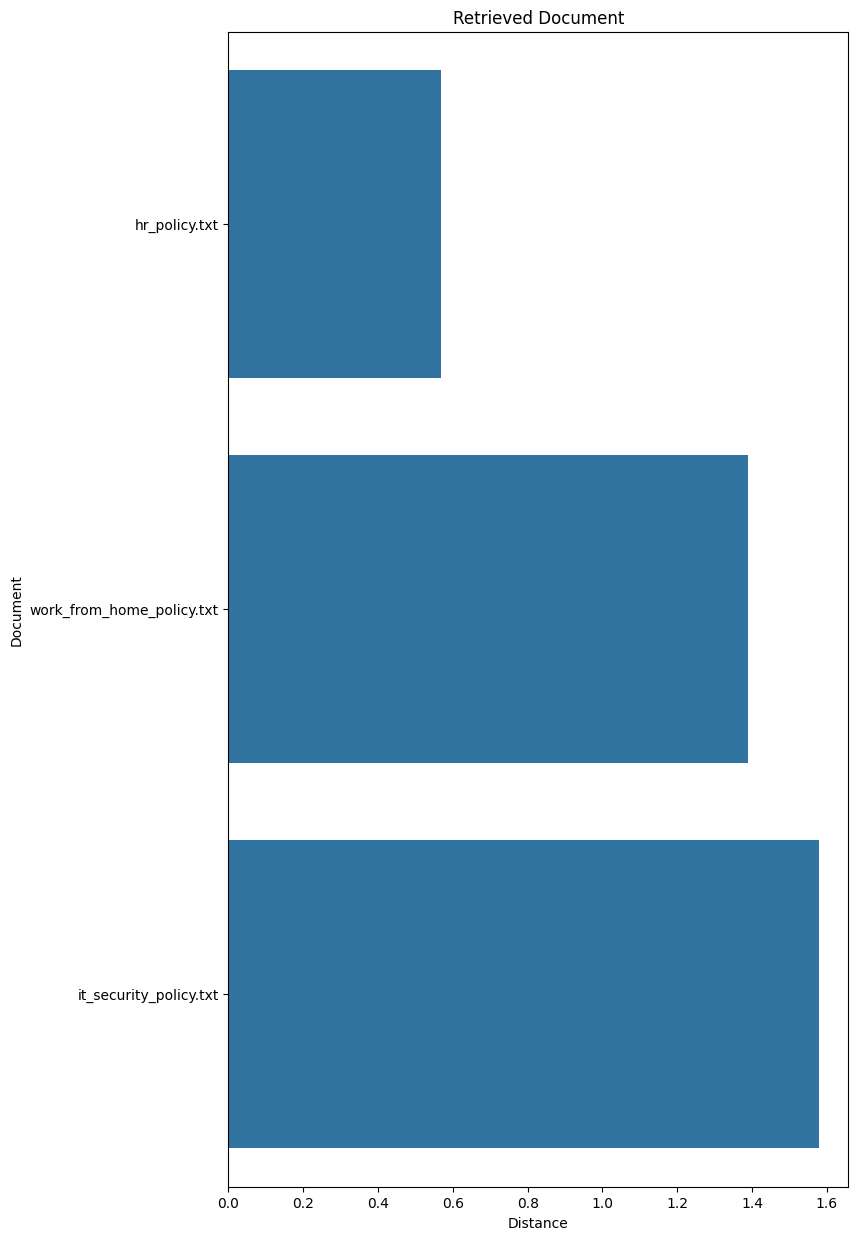

In [17]:
plt.figure(figsize=(8,15))
sns.barplot(
    data= results,
    x= "Distance",
    y= "Document"
)
plt.title("Retrieved Document")
plt.xlabel("Distance")
plt.ylabel("Document")
plt.show()

In [18]:
def ask_gemini(question, top_k=4, history=""):
    results = retrieve_documents(
        question,
        top_k=top_k
    )
    context = ""
    for i in range(len(results)):
        context += (
            "Source: "
            + results.iloc[i]["Document"]
            + "\n"
        )
        context += (
            results.iloc[i]["Chunk"]
            + "\n\n"
        )
    prompt = f"""
You are an Enterprise Knowledge Assistant.

Answer the user's question using ONLY the supplied context.

Do not invent information.

If the answer is not available in the context,
say that the information is not available in the
uploaded documents.

Mention the source document when possible.

Previous conversation:
{history}

Context:
{context}

User Question:
{question}
"""
    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt
    )
    return response.text, results

In [19]:
question= "how many paid leave days are available?"
answer, sources= ask_gemini(question)
print("AI ANSWER:")
print(answer)

print("\nSOURCES:")
print(sources[["Document", "Distance"]])

AI ANSWER:
According to the `hr_policy.txt` document, employees receive 18 paid leave days per year.

SOURCES:
                    Document  Distance
2              hr_policy.txt  0.670522
0  work_from_home_policy.txt  1.445143
1     it_security_policy.txt  1.757123


In [20]:
question = "What should employees do when they receive suspicious emails?"

answer, sources = ask_gemini(question)

print("AI ANSWER:")
print(answer)

print("\nSOURCES:")
print(sources[["Document", "Distance"]])

AI ANSWER:
According to the **it_security_policy.txt** document, employees must report suspicious emails to the IT security team.

SOURCES:
                    Document  Distance
1     it_security_policy.txt  1.314985
0  work_from_home_policy.txt  1.559632
2              hr_policy.txt  1.682421


In [21]:
question = "What is the company maternity leave policy?"

answer, sources = ask_gemini(question)

print(answer)

Based on the provided documents, the information regarding the company's maternity leave policy is not available in the uploaded documents.


In [22]:
def summarize_document(document_name):

    text = "\n".join(
        chunks_df[
            chunks_df["Document"] == document_name
        ]["Chunk"].tolist()
    )

    prompt = f"""
Summarize the following enterprise document.

Use only the information present in the document.

Document:
{text}
"""

    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt
    )

    return response.text

In [23]:
summary = summarize_document("hr_policy.txt")

print(summary)

Based on the provided document, here is a summary of the Employee Leave Policy:

* **Leave Allowance:** Employees receive 18 paid leave days per year and must check their remaining balance before submitting a request.
* **Requesting Leave:** Planned leave requests must be submitted at least 3 working days in advance. Emergency leave must be reported to the reporting manager as soon as possible.
* **Approval:** Managers are responsible for either approving or rejecting leave requests.


In [26]:
def compare_documents(document1, document2):

    text1 = "\n".join(
        chunks_df[
            chunks_df["Document"] == document1
        ]["Chunk"].tolist()
    )

    text2 = "\n".join(
        chunks_df[
            chunks_df["Document"] == document2
        ]["Chunk"].tolist()
    )

    prompt = f"""
Compare the following two enterprise documents.

Explain:

1. Common points
2. Important differences
3. Practical observations

Document 1:
{text1}

Document 2:
{text2}
"""

    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt
    )

    return response.text

In [27]:
comparison = compare_documents(
    "hr_policy.txt",
    "work_from_home_policy.txt"
)

print(comparison)

Here is a comparative analysis of the two enterprise documents.

---

### 1. Common Points
Despite covering different aspects of employment (time off versus remote work), both policies share several foundational principles of corporate governance:

*   **Managerial Authority and Approval:** In both policies, the manager plays a central role. Leave requests must be approved/rejected by the reporting manager, and WFH requests must be submitted to the manager.
*   **Proactive Planning and Notification:** Both policies discourage last-minute, unannounced absences or schedule changes. They require employees to submit requests in advance (3 days for planned leave; before the workday begins for WFH).
*   **Employee Responsibility and Compliance:** Both documents place the burden of compliance on the employee. Under the Leave Policy, employees must check their own balances. Under the WFH Policy, employees must ensure security compliance and remain available.
*   **Operational Continuity:** Bot

In [28]:
chat_history = []

In [29]:
def chat_with_ai(question):

    global chat_history

    history_text = ""

    for item in chat_history[-3:]:

        history_text += (
            "User: "
            + item["question"]
            + "\n"
        )

        history_text += (
            "AI: "
            + item["answer"]
            + "\n\n"
        )

    answer, sources = ask_gemini(
        question,
        top_k=4,
        history=history_text
    )

    chat_history.append({
        "question": question,
        "answer": answer
    })

    return answer, sources

In [30]:
answer, sources = chat_with_ai(
    "How many paid leave days are available?"
)

print(answer)

answer, sources = chat_with_ai(
    "When should I submit the request?"
)

print(answer)

According to the `hr_policy.txt` document, employees receive 18 paid leave days per year.
Depending on which request you are referring to:

* **Planned Leave Request:** According to the `hr_policy.txt` document, you should submit planned leave requests at least **3 working days before** the leave date. For emergency leave, you should communicate it to your reporting manager as soon as possible.
* **Work From Home Request:** According to the `work_from_home_policy.txt` document, the request should normally be submitted to your manager **before the working day begins**.


In [31]:
def process_question(question):

    if not question.strip():

        return "Please enter a question.", pd.DataFrame()

    answer, sources = ask_gemini(question)

    source_table = sources[
        ["Document", "Distance"]
    ].reset_index(drop=True)

    return answer, source_table

In [32]:
with gr.Blocks(
    title="AI Enterprise Knowledge Copilot"
) as demo:

    gr.Markdown(
        """
        # AI Enterprise Knowledge Copilot

        ### RAG + FAISS + SentenceTransformers + Gemini

        Ask questions about the enterprise documents.
        """
    )

    question = gr.Textbox(
        label="Ask a Question",
        placeholder="Example: How many paid leave days are available?"
    )

    ask_button = gr.Button("Ask AI")

    answer = gr.Textbox(
        label="AI Answer",
        lines=8
    )

    sources = gr.Dataframe(
        label="Retrieved Sources"
    )

    ask_button.click(
        fn=process_question,
        inputs=question,
        outputs=[answer, sources]
    )

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://181a85b72ab30b0ea8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [33]:
uploaded_copilot = None
uploaded_history = []

In [34]:
def process_uploaded_files(files, api_key):

    global uploaded_copilot
    global uploaded_history

    if not api_key:
        return "Please enter your Gemini API key."

    if not files:
        return "Please upload at least one TXT document."

    uploaded_documents = []

    for file in files:

        with open(
            file,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            text = f.read()

        uploaded_documents.append(
            (
                os.path.basename(file),
                text
            )
        )

    uploaded_copilot = {
        "documents": uploaded_documents,
        "client": genai.Client(api_key=api_key)
    }

    uploaded_history = []

    return (
        str(len(uploaded_documents))
        + " documents processed successfully."
    )

In [36]:
import tempfile

def build_uploaded_rag(files, api_key):

    if not api_key:
        return None, "Please enter the Gemini API key."

    if not files:
        return None, "Upload at least one TXT document."

    documents = []

    for file in files:

        with open(
            file,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            text = f.read()

        documents.append(
            (
                os.path.basename(file),
                text
            )
        )

    local_copilot = RAGKnowledgeCopilot(
        api_key=api_key
    )

    local_copilot.add_documents(
        documents
    )

    return local_copilot, (
        f"{len(documents)} documents processed successfully."
    )

In [37]:
class RAGKnowledgeCopilot:

    def __init__(
        self,
        api_key,
        model_name="gemini-2.5-flash"
    ):

        self.client = genai.Client(
            api_key=api_key
        )

        self.model_name = model_name

        self.embedding_model = SentenceTransformer(
            "all-MiniLM-L6-v2"
        )

        self.index = None

        self.chunks_df = pd.DataFrame(
            columns=["Document", "Chunk"]
        )

    def split_text(
        self,
        text,
        chunk_size=80
    ):

        words = text.split()

        chunks = []

        for i in range(
            0,
            len(words),
            chunk_size
        ):

            chunk = " ".join(
                words[i:i + chunk_size]
            )

            if chunk.strip():

                chunks.append(chunk)

        return chunks

    def add_documents(
        self,
        documents
    ):

        records = []

        for document_name, text in documents:

            chunks = self.split_text(text)

            for chunk in chunks:

                records.append({
                    "Document": document_name,
                    "Chunk": chunk
                })

        self.chunks_df = pd.DataFrame(
            records
        )

        embeddings = self.embedding_model.encode(
            self.chunks_df["Chunk"].tolist(),
            convert_to_numpy=True
        ).astype("float32")

        self.index = faiss.IndexFlatL2(
            embeddings.shape[1]
        )

        self.index.add(embeddings)

    def retrieve_documents(
        self,
        question,
        top_k=4
    ):

        question_embedding = (
            self.embedding_model.encode(
                [question],
                convert_to_numpy=True
            ).astype("float32")
        )

        distances, positions = self.index.search(
            question_embedding,
            min(
                top_k,
                len(self.chunks_df)
            )
        )

        result = self.chunks_df.iloc[
            positions[0]
        ].copy()

        result["Distance"] = distances[0]

        return result

    def ask_question(
        self,
        question,
        history=""
    ):

        results = self.retrieve_documents(
            question
        )

        context = ""

        for i in range(len(results)):

            context += (
                "Source: "
                + results.iloc[i]["Document"]
                + "\n"
            )

            context += (
                results.iloc[i]["Chunk"]
                + "\n\n"
            )

        prompt = f"""
Answer only using the supplied context.

Do not invent facts.

If the answer is unavailable,
say that it is not available
in the uploaded documents.

Previous conversation:
{history}

Context:
{context}

Question:
{question}
"""

        response = self.client.models.generate_content(
            model=self.model_name,
            contents=prompt
        )

        return response.text, results

In [38]:
current_copilot = None

In [39]:
def load_documents(files, api_key):

    global current_copilot

    current_copilot, message = build_uploaded_rag(
        files,
        api_key
    )

    return message

In [40]:
def ask_uploaded_documents(question):

    global current_copilot

    if current_copilot is None:

        return (
            "Please upload and process documents first.",
            pd.DataFrame()
        )

    if not question.strip():

        return (
            "Please enter a question.",
            pd.DataFrame()
        )

    answer, sources = (
        current_copilot.ask_question(
            question
        )
    )

    return (
        answer,
        sources[
            ["Document", "Distance"]
        ]
    )

In [41]:
def ask_uploaded_documents(question):

    global current_copilot

    if current_copilot is None:

        return (
            "Please upload and process documents first.",
            pd.DataFrame()
        )

    if not question.strip():

        return (
            "Please enter a question.",
            pd.DataFrame()
        )

    answer, sources = (
        current_copilot.ask_question(
            question
        )
    )

    return (
        answer,
        sources[
            ["Document", "Distance"]
        ]
    )

In [42]:
with gr.Blocks(
    title="AI Enterprise Knowledge Copilot"
) as demo:

    gr.Markdown(
        """
        # AI Enterprise Knowledge Copilot

        **RAG + FAISS + SentenceTransformers + Gemini**

        Upload enterprise documents and ask questions
        using natural language.
        """
    )

    with gr.Row():

        api_key = gr.Textbox(
            label="Gemini API Key",
            type="password"
        )

        files = gr.File(
            label="Upload TXT Documents",
            file_count="multiple",
            file_types=[".txt"],
            type="filepath"
        )

    process_button = gr.Button(
        "Process Documents"
    )

    status = gr.Textbox(
        label="Processing Status"
    )

    process_button.click(
        fn=load_documents,
        inputs=[
            files,
            api_key
        ],
        outputs=status
    )

    gr.Markdown(
        "---"
    )

    question = gr.Textbox(
        label="Ask a Question",
        placeholder="Example: What should employees do if they receive a suspicious email?"
    )

    ask_button = gr.Button(
        "Ask AI"
    )

    answer = gr.Textbox(
        label="AI Answer",
        lines=8
    )

    sources = gr.Dataframe(
        label="Retrieved Sources"
    )

    ask_button.click(
        fn=ask_uploaded_documents,
        inputs=question,
        outputs=[
            answer,
            sources
        ]
    )

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff0fd7dbd3f938b3ad.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
